In [35]:
import numpy as np
import json
import matplotlib.pyplot as plt

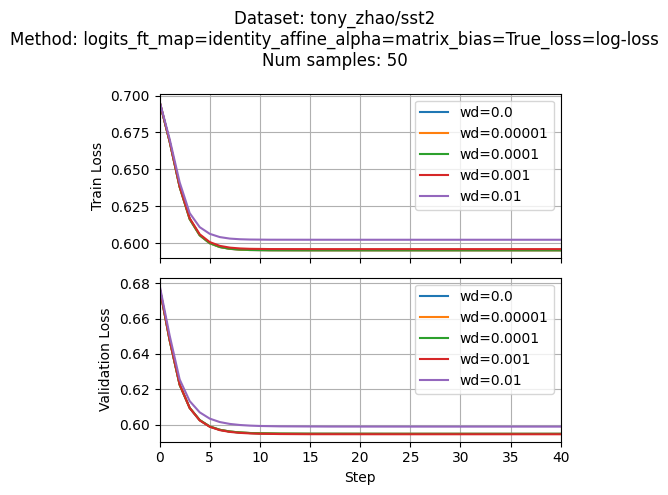

In [36]:
model = "gpt2-xl"
dataset = "tony_zhao/sst2"
num_samples = 50
# method = "logits_ft_map=identity_mahalanobis"
# method = "logits_ft_map=identity_mahalanobis_qr"
method = "logits_ft_map=identity_affine_alpha=matrix_bias=True_loss=log-loss"
weight_decay = ["0.0", "0.00001", "0.0001", "0.001", "0.01"]
# weight_decay = ["0.0", "0.00001", "0.0001", "0.001"]

fig, ax = plt.subplots(2,1, figsize=(5,5), sharex=True)
for wd in weight_decay:
    path = f"../results/tune_calibration/{model}/{dataset}/0_shot--wd={wd}--num_samples={num_samples}/{method}/history.json"
    with open(path, "r") as f:
        history = json.load(f)

    ax[0].plot(history["train_loss"], label=f"wd={wd}")
    ax[0].set_ylabel("Train Loss")
    ax[1].plot(history["validation_loss"], label=f"wd={wd}")
    ax[1].set_ylabel("Validation Loss")
    ax[1].set_xlabel("Step")

    # ax.set_yscale("log")
    ax[0].legend()
    ax[0].grid()
    
    ax[1].legend()
    ax[1].grid()
    ax[1].set_xlim(0, 40)
    

fig.suptitle(f"Dataset: {dataset}\nMethod: {method}\nNum samples: {num_samples}")
fig.tight_layout()
plt.show()